In [1]:
import sys
import os
import glob
import yaml
import random
import numpy as np
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# --- Add your 'src' directory to the Python path ---
if '../src' not in sys.path:
    sys.path.append('../src')

from models import build_model

# --- CONFIGURATION: SET THESE PATHS AND PARAMETERS ---
CONFIG_PATH = '../configs/config.yaml'
MODEL_PATH = '../checkpoints_cv3/unet/20250828_191431_unet_se_resnext50_32x4d_bce0.5_tversky1.0_a0.3_b0.7/fold_1/best_model_soft_dice.pth'
NUM_EXAMPLE_IMAGES = 3
PATCHES_PER_IMAGE_TO_SHOW = 3 # Show the 3 most interesting patches per image
CONFIDENCE_THRESH = 0.5
OUTPUT_DIR = 'pseudolabel_visuals_patched0.5'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ---------------------------------------------------

conf = yaml.safe_load(open(CONFIG_PATH))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/data/smadper@alumno.upv.es/miniconda3/envs/tfm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def get_unlabeled_files(image_dir, mask_dir):
    """Finds all image files that do not have a corresponding mask."""
    all_image_files = set(os.path.basename(f) for f in glob.glob(os.path.join(image_dir, '*.tif')))
    labeled_files = set(os.path.basename(f) for f in glob.glob(os.path.join(mask_dir, '*.tif')))
    unlabeled_files = sorted(list(all_image_files - labeled_files))
    return unlabeled_files

def preprocess_patch(image_patch_np):
    """Applies normalization and tensor conversion to a single patch."""
    transforms = A.Compose([
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2()
    ])
    transformed = transforms(image=image_patch_np)
    return transformed['image'].unsqueeze(0).to(device)

def predict(model, image_tensor):
    """Runs inference and returns the probability map as a numpy array."""
    with torch.no_grad():
        logits = model(image_tensor)
        if isinstance(logits, tuple):
            logits = logits[0]
        probs = torch.sigmoid(logits)
    return probs.squeeze().cpu().numpy()

def create_confidence_viz(prob_map, high_thresh, low_thresh):
    """Creates a 3-color visualization of model confidence."""
    h, w = prob_map.shape
    viz = np.zeros((h, w, 3), dtype=np.uint8)
    
    confident_fg = prob_map > high_thresh
    confident_bg = prob_map < low_thresh
    uncertain = ~(confident_fg | confident_bg)
    
    viz[uncertain] = [128, 128, 128]  # Gray for uncertain
    viz[confident_bg] = [0, 0, 128]     # Dark Blue for confident background
    viz[confident_fg] = [0, 255, 0]    # Bright Green for confident foreground
    
    return viz

def get_patch_interest_score(prob_map, high_thresh):
    """Calculates a score for how 'interesting' a patch is."""
    # A good patch has a mix of high-confidence foreground and other areas.
    # We can approximate this by looking at the number of confident foreground pixels
    # and how spread out they are.
    confident_fg_mask = prob_map > high_thresh
    fg_pixel_count = np.sum(confident_fg_mask)
    
    # Avoid patches with no or too many confident pixels (likely all background or all foreground)
    if fg_pixel_count < 100 or fg_pixel_count > (prob_map.size * 0.8):
        return 0
        
    # A simple score: number of confident pixels
    return fg_pixel_count

: 

Loading champion model from ../checkpoints_cv3/unet/20250828_191431_unet_se_resnext50_32x4d_bce0.5_tversky1.0_a0.3_b0.7/fold_1/best_model_soft_dice.pth
Found 38 unlabeled files. Visualizing patches from 3 images...

Processing Hoja 26-1.tif...


Analyzing patches for Hoja 26-1.tif: 100%|██████████| 8/8 [00:46<00:00,  5.78s/it]


Found 84 interesting patches. Displaying top 3.


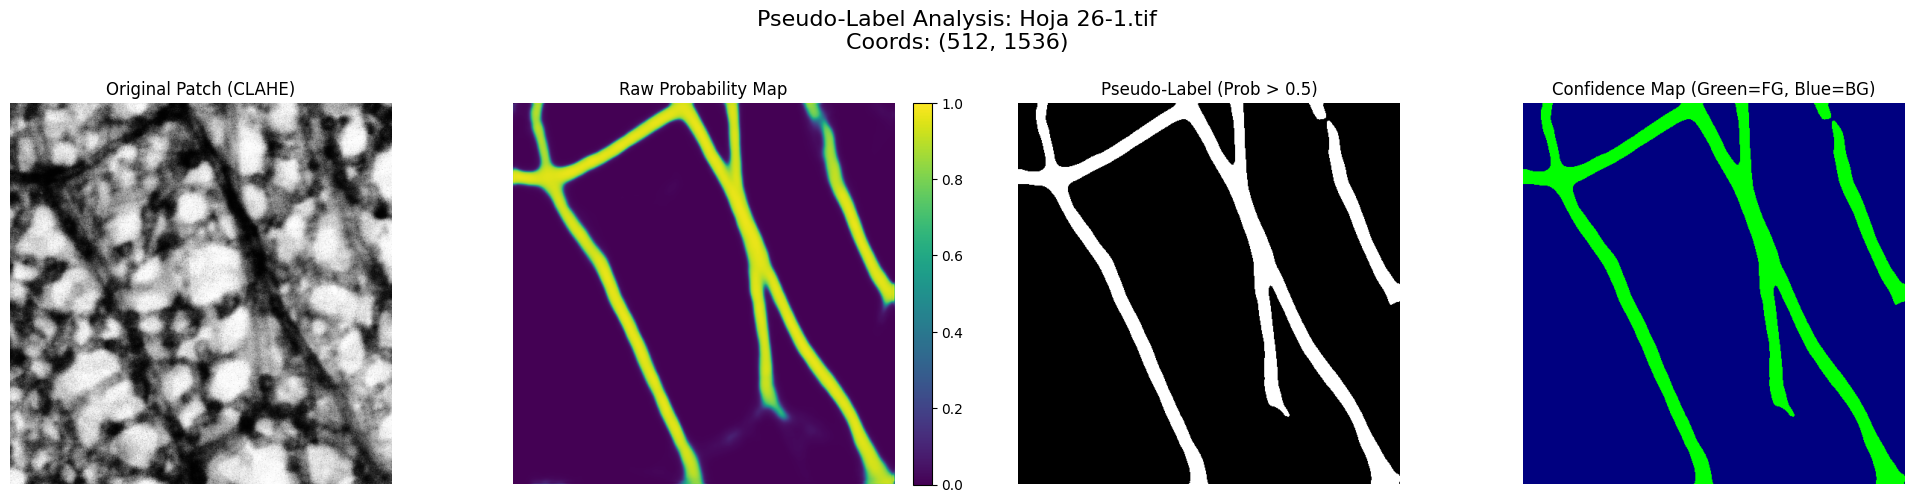

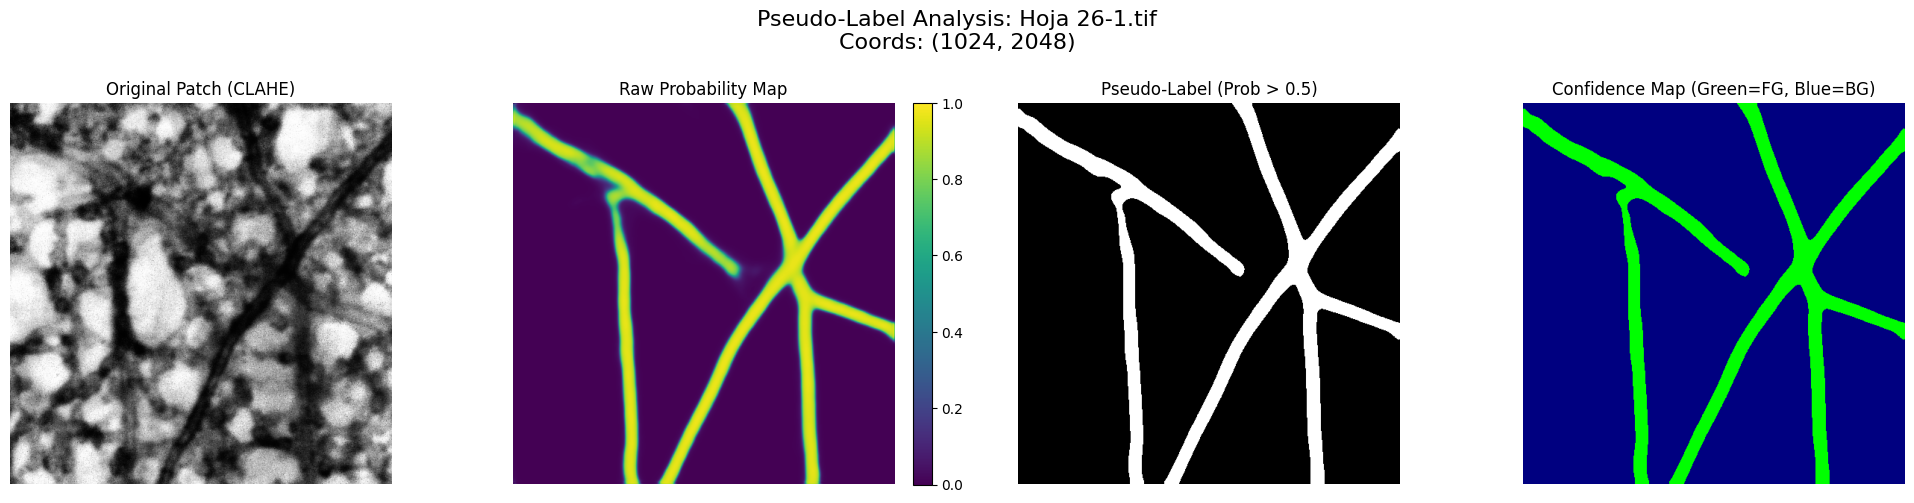

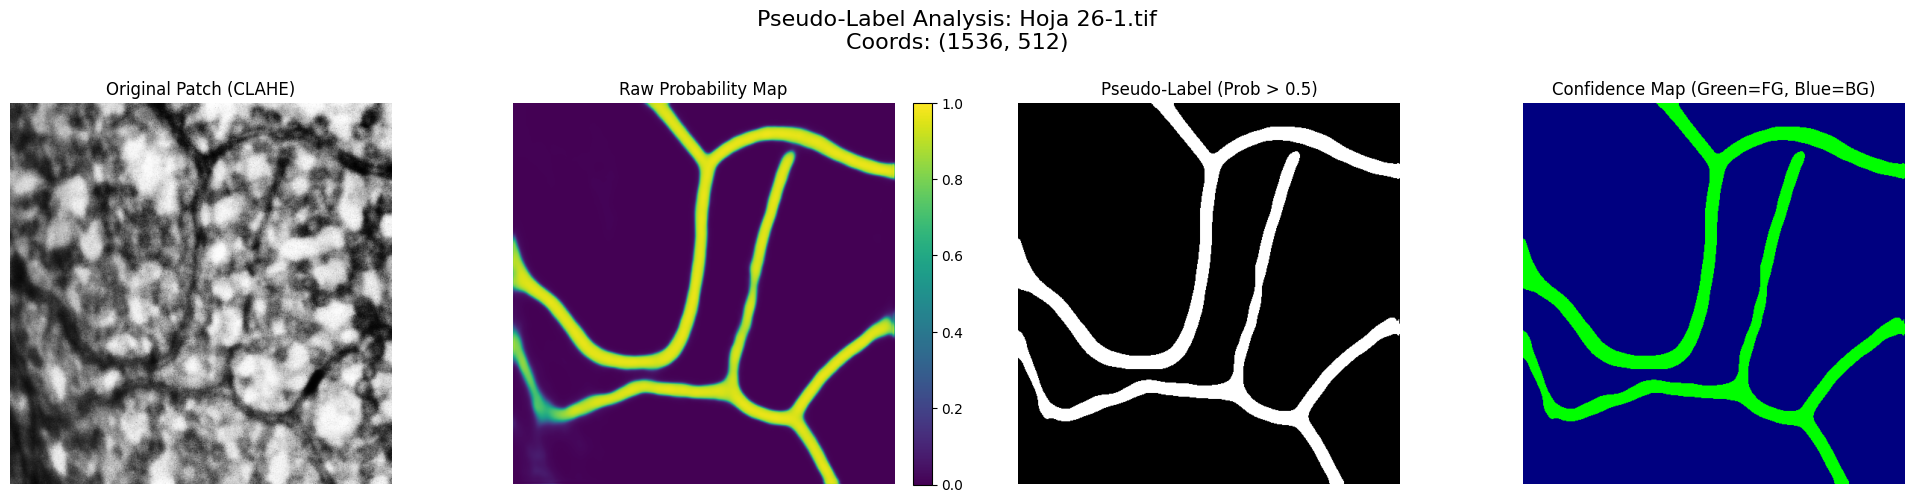


Processing Hoja 22 enves40.jpg (green).tif...


Analyzing patches for Hoja 22 enves40.jpg (green).tif:  62%|██████▎   | 5/8 [00:29<00:17,  5.96s/it]

In [ ]:
# --- Load the trained model ---
print(f"Loading champion model from {MODEL_PATH}")
model = build_model(conf)
# If you saved the full model use this:
# model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
# If you saved just the state_dict, use this:
model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.to(device)
model.eval()

# --- Get unlabeled files ---
image_dir = conf['dataset']['feature_dirs']['image']
mask_dir = conf['dataset']['feature_dirs']['mask']
unlabeled_files = get_unlabeled_files(image_dir, mask_dir)

if not unlabeled_files:
    print("No unlabeled files found. Please check your dataset paths.")
else:
    print(f"Found {len(unlabeled_files)} unlabeled files. Visualizing patches from {NUM_EXAMPLE_IMAGES} images...")

# --- Loop through a sample of unlabeled images ---
for filename in random.sample(unlabeled_files, min(NUM_EXAMPLE_IMAGES, len(unlabeled_files))):
    print(f"\nProcessing {filename}...")
    
    # 1. Load the full-size image and apply CLAHE
    image_path = os.path.join(image_dir, filename)
    original_np = np.array(Image.open(image_path).convert("L"))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply(original_np)
    
    H, W = image_clahe.shape
    patch_h, patch_w = tuple(conf['dataset']['patch_size'])
    
    # 2. Iterate through the image with a sliding window
    patch_results = []
    stride = patch_h // 2 # 50% overlap
    
    for i in tqdm(range(0, H - patch_h + 1, stride), desc=f"Analyzing patches for {filename}"):
        for j in range(0, W - patch_w + 1, stride):
            # Extract patch
            patch_np = image_clahe[i:i+patch_h, j:j+patch_w]
            
            # Preprocess and get prediction
            input_tensor = preprocess_patch(patch_np)
            prob_map = predict(model, input_tensor)
            
            # Score the patch for how interesting it is
            score = get_patch_interest_score(prob_map, CONFIDENCE_THRESH)
            
            if score > 0:
                patch_results.append({
                    "score": score,
                    "image_patch": patch_np,
                    "prob_map": prob_map,
                    "coords": (i, j)
                })

    # 3. Sort the patches by interest score and visualize the top N
    patch_results.sort(key=lambda x: x['score'], reverse=True)
    
    print(f"Found {len(patch_results)} interesting patches. Displaying top {PATCHES_PER_IMAGE_TO_SHOW}.")
    
    for i in range(min(PATCHES_PER_IMAGE_TO_SHOW, len(patch_results))):
        result = patch_results[i]
        prob_map = result['prob_map']
        
        # Generate the visuals for this patch
        pseudo_label = (prob_map > CONFIDENCE_THRESH).astype(np.uint8) * 255
        low_confidence_thresh = 1 - CONFIDENCE_THRESH
        confidence_viz = create_confidence_viz(prob_map, CONFIDENCE_THRESH, low_confidence_thresh)
        
        # Create the plot
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        coords_str = f"Coords: ({result['coords'][0]}, {result['coords'][1]})"
        fig.suptitle(f'Pseudo-Label Analysis: {filename}\n{coords_str}', fontsize=16)

        axes[0].imshow(result['image_patch'], cmap='gray')
        axes[0].set_title('Original Patch (CLAHE)')
        
        im = axes[1].imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        axes[1].set_title('Raw Probability Map')
        fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        
        axes[2].imshow(pseudo_label, cmap='gray')
        axes[2].set_title(f'Pseudo-Label (Prob > {CONFIDENCE_THRESH})')
        
        axes[3].imshow(confidence_viz)
        axes[3].set_title('Confidence Map (Green=FG, Blue=BG)')

        for ax in axes:
            ax.axis('off')
            
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        save_path = os.path.join(OUTPUT_DIR, f"{os.path.splitext(filename)[0]}_patch_{result['coords'][0]}_{result['coords'][1]}.png")
        plt.savefig(save_path, dpi=150)
        plt.show()

print(f"\nVisualizations saved to '{OUTPUT_DIR}' directory.")